In [1]:
# Import 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from textblob import TextBlob

from scipy.stats import (
    pearsonr,
    spearmanr,
    ttest_ind,
    chi2_contingency
)

import statsmodels.api as sm
import statsmodels.formula.api as smf

from IPython.display import display, Markdown
from ollama import chat

In [ ]:
#Ollama AI Summary 
def ai_summary(title, results_text):
    """
    Uses Ollama to interpret statistical results.
    """

    prompt = f"""
You are a data analyst explaining statistical results in simple terms.

Analyze the following output:

TITLE: {title}

RESULTS:
{results_text}

Rules:
- Explain what the results mean in plain English
- Do NOT repeat raw numbers
- Highlight key patterns or differences
- Mention if results suggest meaningful differences
- Keep it short (5–10 sentences max)
"""

    response = chat(
        model="llama3.2:3b", # CH model name was only llama3.2 which did not work for me
        messages=[{"role": "user", "content": prompt}]
    )

    return response["message"]["content"]


def display_ai_summary(title, results_text):
    """
    Displays AI interpretation in notebook.
    """

    try:
        summary = ai_summary(title, results_text)
        display(Markdown("### 🤖 AI Interpretation"))
        display(Markdown(summary))

    except Exception as e:
        print("⚠️ AI summary unavailable (Ollama not running)")
        print(e)

In [9]:
display_ai_summary(
    "Test Summary",
    "Mean sentiment is 0.12 for positive group and -0.30 for negative group."
)


### 🤖 AI Interpretation

Let's break down these results:

The analysis found that people in the positive group generally felt more positively about something, while those in the negative group felt more negatively. The main difference between the two groups is the overall tone of their feelings.

Key differences are seen between the two groups: one group tends to have a stronger feeling of positivity, whereas the other has a stronger feeling of negativity. However, we can't be entirely sure if these feelings truly suggest any significant differences that are meaningful in context.

Overall, the results provide some insight into how people perceive or feel about certain things but don't necessarily imply that one group is significantly better or worse off than the other.

In [3]:
# Quick health checks for Ollama + llama3.2:3b
import json
import urllib.request
import urllib.error

OLLAMA_BASE_URL = "http://localhost:11434"
MODEL = "llama3.2:3b"

def check_ollama_running(base_url=OLLAMA_BASE_URL):
    """Return True if Ollama responds to /api/version."""
    try:
        with urllib.request.urlopen(f"{base_url}/api/version", timeout=5) as resp:
            data = json.loads(resp.read().decode("utf-8"))
            print("PASS: Ollama is reachable.", data)
            return True
    except Exception as exc:
        print("FAIL: Ollama is not reachable at", base_url)
        print("Error:", exc)
        return False

def check_model_installed(model=MODEL, base_url=OLLAMA_BASE_URL):
    """Return True if model name appears in /api/tags."""
    try:
        with urllib.request.urlopen(f"{base_url}/api/tags", timeout=10) as resp:
            payload = json.loads(resp.read().decode("utf-8"))
            models = [m.get("name", "") for m in payload.get("models", [])]
            if model in models:
                print(f"PASS: Model '{model}' is installed.")
                return True
            print(f"FAIL: Model '{model}' not found in local Ollama tags.")
            print("Available models:", models)
            return False
    except Exception as exc:
        print("FAIL: Could not query model tags.")
        print("Error:", exc)
        return False

def test_model_generation(model=MODEL, base_url=OLLAMA_BASE_URL):
    """Run a tiny generation request and print sample output."""
    req_body = {
        "model": model,
        "prompt": "Reply with exactly: OK",
        "stream": False
    }
    data = json.dumps(req_body).encode("utf-8")
    req = urllib.request.Request(
        f"{base_url}/api/generate",
        data=data,
        headers={"Content-Type": "application/json"},
        method="POST",
    )

    try:
        with urllib.request.urlopen(req, timeout=60) as resp:
            result = json.loads(resp.read().decode("utf-8"))
            text = (result.get("response") or "").strip()
            print("PASS: Generation request succeeded.")
            print("Model response:", repr(text))
            return True
    except urllib.error.HTTPError as exc:
        body = exc.read().decode("utf-8", errors="ignore")
        print("FAIL: Generation request failed with HTTP", exc.code)
        print("Response body:", body)
        return False
    except Exception as exc:
        print("FAIL: Generation request failed.")
        print("Error:", exc)
        return False

# Run tests
is_up = check_ollama_running()
has_model = check_model_installed()
can_generate = test_model_generation() if (is_up and has_model) else False

print("\nSummary:")
print("- Ollama running:", is_up)
print("- Model installed:", has_model)
print("- Generation works:", can_generate)

PASS: Ollama is reachable. {'version': '0.30.7'}
PASS: Model 'llama3.2:3b' is installed.
PASS: Generation request succeeded.
Model response: 'OK'

Summary:
- Ollama running: True
- Model installed: True
- Generation works: True


In [10]:
import pandas as pd

input_file = 'reviews_BlackOps7.csv'
df = pd.read_csv(input_file)

print(f"Loaded {len(df)} rows")
display(df.head())

Loaded 1110 rows


,review,author_vote,other_votes,weighted_vote_score,review_date
0,I really do not understand the hate this game ...,1,0,0.500000,2026-07-10
1,"This game is, absolute, unique, I really enjoy...",0,0,0.500000,2026-07-10
2,likely will regret buying on the summer sale. ...,0,3,0.518519,2026-07-09
3,"Omg y'all are some big babies, this game is fi...",1,2,0.366231,2026-07-09
4,"No matter if you have a great GPU & CPU, they ...",0,12,0.620229,2026-07-08


In [11]:
#Sentiment and Categorization
def get_sentiment(text):
    """
    Returns sentiment polarity score (-1 to 1).
    """
    if pd.isna(text):
        return 0.0

    return TextBlob(str(text)).sentiment.polarity

In [12]:
def categorize_review(review):
    """
    Assigns categories based on keyword matching.
    """

    if pd.isna(review):
        return ["Game Reception"]

    review_lower = str(review).lower()

    keyword_map = {
        "Usability_Issues": [
            "bug", "crash", "lag", "fps", "stutter", "freeze",
            "disconnect", "error", "broken", "unoptimized", "latency"
        ],

        "New_Mechanic_Reception": [
            "movement", "weapon", "perk", "loadout", "gunplay",
            "ttk", "aim assist", "map", "game mode"
        ],

        "Competitive_Analysis": [
            "better than", "worse than", "compared to", "similar to",
            "feels like", "reminds me of", "old cod"
        ],

        "AI_Generated_Content_Complaints": [
            "ai", "slop", "lazy", "copy paste", "no effort", "soulless"
        ],

        "Monetization_and_Value": [
            "price", "worth", "overpriced", "microtransaction",
            "battle pass", "store", "bundle", "pay"
        ],

        "Story___Campaign": [
            "campaign", "story", "mission", "cutscene", "character", "plot"
        ],

        "Technical_Requirements": [
            "secure boot", "tpm", "anti-cheat", "kernel", "driver"
        ],

        "SBMM___Matchmaking_Frustration": [
            "sbmm", "matchmaking", "sweaty", "lobby", "ranked"
        ],

        "Community_and_Social": [
            "friends", "team", "party", "toxic", "voice", "chat"
        ]
    }

    categories = []

    for category, keywords in keyword_map.items():
        if any(word in review_lower for word in keywords):
            categories.append(category)

    if len(categories) == 0:
        categories.append("Game_Reception")

    return categories

In [13]:
sentiments = []
categories = []

for r in df["review"]:
    sentiments.append(get_sentiment(r))
    categories.append(", ".join(categorize_review(r)))

df["sentiment"] = sentiments
df["categories"] = categories

display(df.head())

,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories
0,I really do not understand the hate this game ...,1,0,0.500000,2026-07-10,0.086667,"New_Mechanic_Reception, AI_Generated_Content_C..."
1,"This game is, absolute, unique, I really enjoy...",0,0,0.500000,2026-07-10,0.019105,"AI_Generated_Content_Complaints, Story___Campa..."
2,likely will regret buying on the summer sale. ...,0,3,0.518519,2026-07-09,-0.400000,Game_Reception
3,"Omg y'all are some big babies, this game is fi...",1,2,0.366231,2026-07-09,-0.043182,AI_Generated_Content_Complaints
4,"No matter if you have a great GPU & CPU, they ...",0,12,0.620229,2026-07-08,0.266667,Game_Reception


In [14]:
# Remove duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicates. {len(df)} rows remaining.")
display(df.head())

Removed 0 duplicates. 1110 rows remaining.


,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories
0,I really do not understand the hate this game ...,1,0,0.500000,2026-07-10,0.086667,"New_Mechanic_Reception, AI_Generated_Content_C..."
1,"This game is, absolute, unique, I really enjoy...",0,0,0.500000,2026-07-10,0.019105,"AI_Generated_Content_Complaints, Story___Campa..."
2,likely will regret buying on the summer sale. ...,0,3,0.518519,2026-07-09,-0.400000,Game_Reception
3,"Omg y'all are some big babies, this game is fi...",1,2,0.366231,2026-07-09,-0.043182,AI_Generated_Content_Complaints
4,"No matter if you have a great GPU & CPU, they ...",0,12,0.620229,2026-07-08,0.266667,Game_Reception


In [15]:
#Feature engineering
df["review_length"] = df["review"].astype(str).str.len()
df["word_count"] = df["review"].astype(str).str.split().str.len()
df["sentiment_strength"] = df["sentiment"].abs()

print("Feature engineering complete.")
display(df[["review_length", "word_count", "sentiment", "sentiment_strength"]].head())

Feature engineering complete.


,review_length,word_count,sentiment,sentiment_strength
0,694,143,0.086667,0.086667
1,708,142,0.019105,0.019105
2,173,29,-0.400000,0.400000
3,280,51,-0.043182,0.043182
4,310,60,0.266667,0.266667


In [16]:
# Category Columns
all_categories = [
    "Usability_Issues",
    "New_Mechanic_Reception",
    "Competitive_Analysis",
    "AI_Generated_Content_Complaints",
    "Monetization_and_Value",
    "Story___Campaign",
    "Technical_Requirements",
    "SBMM___Matchmaking_Frustration",
    "Community_and_Social",
    "Game_Reception"
]

for category in all_categories:
    df[category] = df["categories"].apply(lambda x: category in str(x))

print("Category columns created:")
print(df[all_categories].head())

Category columns created:
   Usability_Issues  New_Mechanic_Reception  Competitive_Analysis  \
0             False                    True                 False   
1             False                   False                 False   
2             False                   False                 False   
3             False                   False                 False   
4             False                   False                 False   

   AI_Generated_Content_Complaints  Monetization_and_Value  Story___Campaign  \
0                             True                    True              True   
1                             True                   False              True   
2                            False                   False             False   
3                             True                   False             False   
4                            False                   False             False   

   Technical_Requirements  SBMM___Matchmaking_Frustration  \
0                

In [17]:
df[all_categories].sum().sort_values(ascending=False)

AI_Generated_Content_Complaints    798
Story___Campaign                   571
New_Mechanic_Reception             446
Monetization_and_Value             243
Competitive_Analysis               230
SBMM___Matchmaking_Frustration     214
Community_and_Social               209
Usability_Issues                   178
Game_Reception                      94
Technical_Requirements              44
dtype: int64

In [ ]:
%pip install textblob


In [18]:
from textblob import TextBlob


# --------------------------
# Sentiment Analysis
# --------------------------

def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity
    return polarity 

    '''
    if polarity > 0.1:
        return "Positive"

    elif polarity < -0.1:
        return "Negative"

    return "Neutral"
    '''

In [19]:

# --------------------------
# Categorization
# --------------------------
def categorize_review(review):

    usability_keywords = [
        "bug",
        "crash",
        "lag",
        "fps",
        "server",
        "performance",

        "glitch",
        "stutter",
        "freeze",
        "disconnect",
        "error",
        "broken",
        "unoptimized",
        "latency",
        "ping",
        "hitbox",
        "connection",
        "frame rate",
        "loading",
        "memory leak",
    ]

    mechanic_keywords = [
        "movement",
        "weapon",
        "perk",
        "battle pass",
        "matchmaking",

        "loadout",
        "killstreak",
        "scorestreak",
        "operator",
        "map",
        "game mode",
        "respawn",
        "spawn",
        "ability",
        "class",
        "gunplay",
        "ttk",
        "time to kill",
        "recoil",
        "aim assist",
        "multiplayer",
        "zombies",
        "campaign",
        "season",
    ]

    comparison_keywords = [
        "better than",
        "worse than",
        "compared to",
        "similar to",
        
        "just like",
        "same as",
        "feels like",
        "plays like",
        "reminds me of",
        "prefer",
        "used to",
        "previous",
        "original",
        "back in",
        "inferior to",
        "superior to",
        "rip off",
        "copy of",
        "old cod",
    ]

    # New categories based on look for categories AI analysis of full review file
    ai_content_keywords = [
        "slop",
        "ai generated",
        "ai slop",
        "no effort",
        "copy paste",
        "lazy",
        "generated content",
        "soulless",
        "cash grab",
    ]

    monetization_keywords = [
        "refund",
        "worth",
        "price",
        "sale",
        "buying",
        "paid",
        "microtransaction",
        "endgame",
        "season pass",
        "overpriced",
        "free to play",
        "cosmetic",
        "store",
        "bundle",
    ]

    story_keywords = [
        "campaign",
        "story",
        "single player",
        "solo",
        "narrative",
        "mission",
        "ending",
        "cutscene",
        "plot",
        "character",
    ]

    technical_requirements_keywords = [
        "secure boot",
        "tpm",
        "bios",
        "hardware",
        "anti-cheat",
        "ricochet",
        "kernel",
        "driver",
        "compatibility",
        "system requirement",
    ]

    sbmm_keywords = [
        "sbmm",
        "skill based",
        "lobbies",
        "lobby",
        "sweaty",
        "ranked",
        "casual",
        "matchmaking",
        "skill gap",
        "pub stomp",
    ]

    community_keywords = [
        "friends",
        "team",
        "squad",
        "banned",
        "toxic",
        "solo",
        "party",
        "coop",
        "co-op",
        "community",
        "chat",
        "voice",
        "grief",
    ]

    review_lower = review.lower()

    categories = []

    if any(word in review_lower for word in usability_keywords):
        categories.append("Usability Issues")

    if any(word in review_lower for word in mechanic_keywords):
        categories.append("New Mechanic Reception")

    if any(word in review_lower for word in comparison_keywords):
        categories.append("Competitive Analysis")

    if any(word in review_lower for word in ai_content_keywords):
        categories.append("AI-Generated Content Complaints")

    if any(word in review_lower for word in monetization_keywords):
        categories.append("Monetization & Value")

    if any(word in review_lower for word in story_keywords):
        categories.append("Story / Campaign")

    if any(word in review_lower for word in technical_requirements_keywords):
        categories.append("Technical Requirements")

    if any(word in review_lower for word in sbmm_keywords):
        categories.append("SBMM / Matchmaking Frustration")

    if any(word in review_lower for word in community_keywords):
        categories.append("Community & Social")

    if len(categories) == 0:
        categories.append("Game Reception")

    return categories


In [ ]:
# AI Statistical Summary Function
# ------------------------------------

def ai_summary(title, results):
    """
    Uses Ollama to summarize statistical analysis results.
    """

    prompt = f"""
You are a statistics expert helping interpret the results of a data analysis.

Analysis:
{title}

Results:
{results}

Write a concise summary (2–4 sentences).

Your summary should:
- Explain the results in plain English.
- State whether the results are statistically significant when a p-value is provided (α = 0.05).
- Explain what the results mean.
- Do not speculate beyond the data.
"""

    response = chat(
        model="llama3.1",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.message.content


def display_ai_summary(title, results):

    summary = ai_summary(title, results)

    display(Markdown("### 🤖 AI Statistical Interpretation"))

    display(Markdown(summary))

In [20]:
# Run sentiment analysis and categorization, then save to a new CSV
sentiments = []
categories = []

for r in df['review']:
    sentiments.append(get_sentiment(r))
    categories.append(', '.join(categorize_review(r)))

df['sentiment'] = sentiments
df['categories'] = categories

display(df)

,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,review_length,word_count,sentiment_strength,Usability_Issues,New_Mechanic_Reception,Competitive_Analysis,AI_Generated_Content_Complaints,Monetization_and_Value,Story___Campaign,Technical_Requirements,SBMM___Matchmaking_Frustration,Community_and_Social,Game_Reception
0,I really do not understand the hate this game ...,1,0,0.500000,2026-07-10,0.086667,"New Mechanic Reception, Monetization & Value, ...",694,143,0.086667,False,True,False,True,True,True,False,False,True,False
1,"This game is, absolute, unique, I really enjoy...",0,0,0.500000,2026-07-10,0.019105,"New Mechanic Reception, Story / Campaign, Comm...",708,142,0.019105,False,False,False,True,False,True,False,False,True,False
2,likely will regret buying on the summer sale. ...,0,3,0.518519,2026-07-09,-0.400000,Monetization & Value,173,29,0.400000,False,False,False,False,False,False,False,False,False,True
3,"Omg y'all are some big babies, this game is fi...",1,2,0.366231,2026-07-09,-0.043182,New Mechanic Reception,280,51,0.043182,False,False,False,True,False,False,False,False,False,False
4,"No matter if you have a great GPU & CPU, they ...",0,12,0.620229,2026-07-08,0.266667,Technical Requirements,310,60,0.266667,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1105,I dont think the $70 price tag for BO7 is inhe...,0,1,0.523810,2025-11-13,0.058132,"New Mechanic Reception, Competitive Analysis, ...",1589,275,0.058132,False,True,True,True,True,True,False,False,True,False
1106,Edited: Im sorry but this game is absolutely t...,0,0,0.275451,2025-11-13,-0.090879,"Usability Issues, Competitive Analysis, Moneti...",457,85,0.090879,False,False,False,True,False,False,False,False,False,False
1107,They finally fixed the SBMM and brought back p...,1,30,0.291598,2025-11-13,0.350000,"Usability Issues, New Mechanic Reception, Comp...",266,43,0.350000,False,True,True,False,True,False,False,True,False,False
1108,The first couple of weeks of BO7 are gonna be ...,0,4277,0.913367,2025-11-13,0.146032,"Usability Issues, New Mechanic Reception, Mone...",729,129,0.146032,False,True,False,True,False,False,False,False,False,False


In [21]:
# Add a boolean column for each possible category
all_categories = [
    "Usability Issues",
    "New Mechanic Reception",
    "Competitive Analysis",
    "AI-Generated Content Complaints",
    "Monetization & Value",
    "Story / Campaign",
    "Technical Requirements",
    "SBMM / Matchmaking Frustration",
    "Community & Social",
    "Game Reception",
]

for category in all_categories:
    col_name = category.replace(" ", "_").replace("/", "_").replace("&", "and").replace("-", "_")
    col_values = []
    for cat_list in df['categories']:
        col_values.append(category in cat_list)
    df[col_name] = col_values

display(df.head(20))


,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,review_length,word_count,sentiment_strength,Usability_Issues,New_Mechanic_Reception,Competitive_Analysis,AI_Generated_Content_Complaints,Monetization_and_Value,Story___Campaign,Technical_Requirements,SBMM___Matchmaking_Frustration,Community_and_Social,Game_Reception
0,I really do not understand the hate this game ...,1,0,0.500000,2026-07-10,0.086667,"New Mechanic Reception, Monetization & Value, ...",694,143,0.086667,False,True,False,False,True,True,False,False,True,False
1,"This game is, absolute, unique, I really enjoy...",0,0,0.500000,2026-07-10,0.019105,"New Mechanic Reception, Story / Campaign, Comm...",708,142,0.019105,False,True,False,False,False,True,False,False,True,False
2,likely will regret buying on the summer sale. ...,0,3,0.518519,2026-07-09,-0.400000,Monetization & Value,173,29,0.400000,False,False,False,False,True,False,False,False,False,False
3,"Omg y'all are some big babies, this game is fi...",1,2,0.366231,2026-07-09,-0.043182,New Mechanic Reception,280,51,0.043182,False,True,False,False,False,False,False,False,False,False
4,"No matter if you have a great GPU & CPU, they ...",0,12,0.620229,2026-07-08,0.266667,Technical Requirements,310,60,0.266667,False,False,False,False,False,False,True,False,False,False
5,This campaign is dogsh** as f*ck you can't eve...,1,3,0.485478,2026-07-08,0.096429,"New Mechanic Reception, Monetization & Value, ...",280,50,0.096429,False,True,False,False,True,True,False,False,False,False
6,Call of Duty have lost its soul with this crap...,0,4,0.527559,2026-07-08,0.011111,New Mechanic Reception,287,58,0.011111,False,True,False,False,False,False,False,False,False,False
7,Great zombies game. Nothing else. Campaign is ...,0,8,0.404882,2026-07-08,-0.218333,"New Mechanic Reception, Story / Campaign",200,36,0.218333,False,True,False,False,False,True,False,False,False,False
8,"Campaign is really really bad, but hey it has ...",1,3,0.424312,2026-07-07,0.152130,"New Mechanic Reception, Monetization & Value, ...",1193,225,0.152130,False,True,False,False,True,True,False,False,False,False
9,campaign isnt that enjoyable compared to other...,0,3,0.504494,2026-07-06,0.076941,"New Mechanic Reception, Competitive Analysis, ...",206,38,0.076941,False,True,True,False,True,True,False,False,False,False


In [22]:
# Category Columns
# ------------------------------------

# Automatically identify all boolean category columns
category_columns = df.select_dtypes(include="bool").columns.tolist()

print(category_columns)

['Usability_Issues', 'New_Mechanic_Reception', 'Competitive_Analysis', 'AI_Generated_Content_Complaints', 'Monetization_and_Value', 'Story___Campaign', 'Technical_Requirements', 'SBMM___Matchmaking_Frustration', 'Community_and_Social', 'Game_Reception']


In [23]:
analyzed_file = input_file.replace('.csv', '_analyzed.csv')

df.to_csv(analyzed_file, index=False)
print(f"Saved {len(df)} analyzed reviews to {analyzed_file}")
df[['review', 'sentiment', 'categories']].head()


Saved 1110 analyzed reviews to reviews_BlackOps7_analyzed.csv


,review,sentiment,categories
0,I really do not understand the hate this game ...,0.086667,"New Mechanic Reception, Monetization & Value, ..."
1,"This game is, absolute, unique, I really enjoy...",0.019105,"New Mechanic Reception, Story / Campaign, Comm..."
2,likely will regret buying on the summer sale. ...,-0.400000,Monetization & Value
3,"Omg y'all are some big babies, this game is fi...",-0.043182,New Mechanic Reception
4,"No matter if you have a great GPU & CPU, they ...",0.266667,Technical Requirements


In [24]:
# Read the analyzed CSV back and convert categories from string to list
df_analyzed = pd.read_csv(analyzed_file)

# Convert the categories column from comma-separated string to list
categories_list = []
for cat_string in df_analyzed['categories']:
    cat_list = []
    for cat in cat_string.split(','):
        cat_list.append(cat.strip())
    categories_list.append(cat_list)

df_analyzed['categories'] = categories_list

print(f"Loaded {len(df_analyzed)} analyzed reviews")
print("\nFirst few rows with categories as lists:")
display(df_analyzed)


Loaded 1110 analyzed reviews

First few rows with categories as lists:


,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,review_length,word_count,sentiment_strength,Usability_Issues,New_Mechanic_Reception,Competitive_Analysis,AI_Generated_Content_Complaints,Monetization_and_Value,Story___Campaign,Technical_Requirements,SBMM___Matchmaking_Frustration,Community_and_Social,Game_Reception
0,I really do not understand the hate this game ...,1,0,0.500000,2026-07-10,0.086667,"[New Mechanic Reception, Monetization & Value,...",694,143,0.086667,False,True,False,False,True,True,False,False,True,False
1,"This game is, absolute, unique, I really enjoy...",0,0,0.500000,2026-07-10,0.019105,"[New Mechanic Reception, Story / Campaign, Com...",708,142,0.019105,False,True,False,False,False,True,False,False,True,False
2,likely will regret buying on the summer sale. ...,0,3,0.518519,2026-07-09,-0.400000,[Monetization & Value],173,29,0.400000,False,False,False,False,True,False,False,False,False,False
3,"Omg y'all are some big babies, this game is fi...",1,2,0.366231,2026-07-09,-0.043182,[New Mechanic Reception],280,51,0.043182,False,True,False,False,False,False,False,False,False,False
4,"No matter if you have a great GPU & CPU, they ...",0,12,0.620229,2026-07-08,0.266667,[Technical Requirements],310,60,0.266667,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1105,I dont think the $70 price tag for BO7 is inhe...,0,1,0.523810,2025-11-13,0.058132,"[New Mechanic Reception, Competitive Analysis,...",1589,275,0.058132,False,True,True,False,True,True,False,False,True,False
1106,Edited: Im sorry but this game is absolutely t...,0,0,0.275451,2025-11-13,-0.090879,"[Usability Issues, Competitive Analysis, Monet...",457,85,0.090879,True,False,True,False,True,False,False,False,False,False
1107,They finally fixed the SBMM and brought back p...,1,30,0.291598,2025-11-13,0.350000,"[Usability Issues, New Mechanic Reception, Com...",266,43,0.350000,True,True,True,False,True,False,False,True,False,False
1108,The first couple of weeks of BO7 are gonna be ...,0,4277,0.913367,2025-11-13,0.146032,"[Usability Issues, New Mechanic Reception, Mon...",729,129,0.146032,True,True,False,False,True,False,False,False,False,False


In [ ]:
# Analysis suggestions:
# What is the number of each of the categories used? (what is the most/least common category)

# Exploratory Data Analysis 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import (
    pearsonr,
    spearmanr,
    ttest_ind,
    chi2_contingency
)

import statsmodels.api as sm
import statsmodels.formula.api as smf

# CH read in csv file here?

In [26]:
# Feature Engineering
# -----------------------------------

df["review_length"] = df["review"].str.len()

df["word_count"] = df["review"].str.split().str.len()

df["sentiment_strength"] = df["sentiment"].abs()

display(df.head())

,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,review_length,word_count,sentiment_strength,Usability_Issues,New_Mechanic_Reception,Competitive_Analysis,AI_Generated_Content_Complaints,Monetization_and_Value,Story___Campaign,Technical_Requirements,SBMM___Matchmaking_Frustration,Community_and_Social,Game_Reception
0,I really do not understand the hate this game ...,1,0,0.500000,2026-07-10,0.086667,"New Mechanic Reception, Monetization & Value, ...",694,143,0.086667,False,True,False,False,True,True,False,False,True,False
1,"This game is, absolute, unique, I really enjoy...",0,0,0.500000,2026-07-10,0.019105,"New Mechanic Reception, Story / Campaign, Comm...",708,142,0.019105,False,True,False,False,False,True,False,False,True,False
2,likely will regret buying on the summer sale. ...,0,3,0.518519,2026-07-09,-0.400000,Monetization & Value,173,29,0.400000,False,False,False,False,True,False,False,False,False,False
3,"Omg y'all are some big babies, this game is fi...",1,2,0.366231,2026-07-09,-0.043182,New Mechanic Reception,280,51,0.043182,False,True,False,False,False,False,False,False,False,False
4,"No matter if you have a great GPU & CPU, they ...",0,12,0.620229,2026-07-08,0.266667,Technical Requirements,310,60,0.266667,False,False,False,False,False,False,True,False,False,False


In [27]:
#Category frequency analysis 

category_counts = (
    df[category_columns]
    .sum()
    .sort_values(ascending=False)
)

display(category_counts)

New_Mechanic_Reception             839
Story___Campaign                   599
Monetization_and_Value             453
Competitive_Analysis               372
Community_and_Social               342
Usability_Issues                   323
SBMM___Matchmaking_Frustration     244
AI_Generated_Content_Complaints    116
Technical_Requirements              68
Game_Reception                      62
dtype: int64

In [28]:
# Analysis Functions (Visuals + Stats + AI Summary)
# ----------------------------
# 1. Histogram
# ----------------------------
def analyze_histogram(df, column, title):
    plt.figure(figsize=(8,5))
    df[column].hist(bins=30)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

    display_ai_summary(title, df[column].describe().to_string())


# ----------------------------
# 2. Bar Chart
# ----------------------------
def analyze_bar_chart(data, title):
    plt.figure(figsize=(10,6))
    data.plot(kind="bar")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display_ai_summary(title, data.to_string())


# ----------------------------
# 3. Box Plot (Category vs Sentiment)
# ----------------------------
def analyze_boxplot(df, category_column, value_column, title):
    df.boxplot(column=value_column, by=category_column)
    plt.title(title)
    plt.suptitle("")
    plt.xticks(rotation=45)
    plt.show()

    results = (
        df.groupby(category_column)[value_column]
          .describe()
          .to_string()
    )

    display_ai_summary(title, results)


# ----------------------------
# 4. Correlation Matrix
# ----------------------------
def analyze_correlation(df, columns, title):
    corr = df[columns].corr()

    display(corr)

    plt.figure(figsize=(8,6))
    plt.imshow(corr, cmap="coolwarm", interpolation="none")
    plt.colorbar()
    plt.xticks(range(len(columns)), columns, rotation=45, ha="right")
    plt.yticks(range(len(columns)), columns)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    display_ai_summary(title, corr.to_string())


# ----------------------------
# 5. T-test helper
# ----------------------------
def analyze_ttest(df, group_col, value_col, title):
    group1 = df[df[group_col] == True][value_col]
    group2 = df[df[group_col] == False][value_col]

    stat, p = ttest_ind(group1, group2, nan_policy="omit")

    result_text = f"""
T-test Results:
Statistic: {stat:.4f}
P-value: {p:.6f}
Group 1 mean: {group1.mean():.4f}
Group 2 mean: {group2.mean():.4f}
"""

    print(result_text)
    display_ai_summary(title, result_text)


# ----------------------------
# 6. Chi-square test
# ----------------------------
def analyze_chi_square(df, col1, col2, title):
    contingency = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(contingency)

    result_text = f"""
Chi-square Results:
Chi2: {chi2:.4f}
P-value: {p:.6f}
Degrees of freedom: {dof}
"""

    print(result_text)
    display_ai_summary(title, result_text)
#7. Regression Analysis
def analyze_regression(df, x_columns, y_column, title):
    """
    Runs linear regression to test relationships between variables
    """

    # Drop missing values for clean model
    data = df[x_columns + [y_column]].dropna()

    X = data[x_columns]
    y = data[y_column]

    # Add intercept
    X = sm.add_constant(X)

    # Fit model
    model = sm.OLS(y, X).fit()

    # Print full statistical output
    print(model.summary())

    # AI interpretation
    display_ai_summary(title, model.summary().as_text())

In [29]:
print("Overall Dataset Statistics")
display(df.describe())

print("\nSentiment Statistics")
display(df["sentiment"].describe())

print("\nReview Length Statistics")
display(df["review_length"].describe())

print("\nWord Count Statistics")
display(df["word_count"].describe())

print("Category Frequencies")

for category in all_categories:

    column = (
        category
        .replace(" ", "_")
        .replace("/", "_")
        .replace("&", "and")
        .replace("-", "_")
    )

    print(f"{category}: {df[column].sum()}")

Overall Dataset Statistics


,author_vote,other_votes,weighted_vote_score,sentiment,review_length,word_count,sentiment_strength
count,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000,1110.000000
mean,0.349550,69.613514,0.479777,-0.019781,740.511712,136.990090,0.147868
std,0.477043,449.078205,0.170450,0.192387,933.241356,170.459653,0.124579
min,0.000000,0.000000,0.048404,-0.733333,24.000000,9.000000,0.000000
25%,0.000000,3.000000,0.337165,-0.134696,264.000000,49.250000,0.053333
50%,0.000000,9.000000,0.509455,-0.008399,439.500000,83.000000,0.120073
75%,1.000000,24.000000,0.572951,0.107002,817.250000,151.000000,0.200000
max,1.000000,9335.000000,0.988064,0.600000,7876.000000,1506.000000,0.733333



Sentiment Statistics


count    1110.000000
mean       -0.019781
std         0.192387
min        -0.733333
25%        -0.134696
50%        -0.008399
75%         0.107002
max         0.600000
Name: sentiment, dtype: float64


Review Length Statistics


count    1110.000000
mean      740.511712
std       933.241356
min        24.000000
25%       264.000000
50%       439.500000
75%       817.250000
max      7876.000000
Name: review_length, dtype: float64


Word Count Statistics


count    1110.000000
mean      136.990090
std       170.459653
min         9.000000
25%        49.250000
50%        83.000000
75%       151.000000
max      1506.000000
Name: word_count, dtype: float64

Category Frequencies
Usability Issues: 323
New Mechanic Reception: 839
Competitive Analysis: 372
AI-Generated Content Complaints: 116
Monetization & Value: 453
Story / Campaign: 599
Technical Requirements: 68
SBMM / Matchmaking Frustration: 244
Community & Social: 342
Game Reception: 62


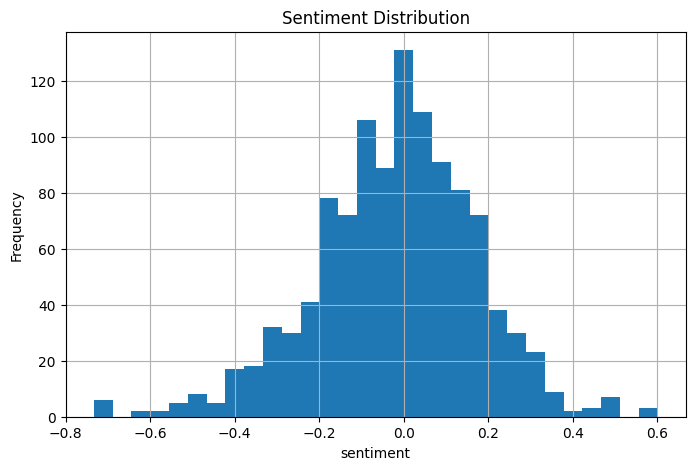

### 🤖 AI Interpretation

This output shows the distribution of sentiment ratings, which are likely based on customer feedback or reviews. The results indicate that:

Most customers have a neutral to slightly negative opinion (50% fall within -0.008399 and 0.107002), but there's a small range where opinions tend to be even more positive (above 0.107002).

There is significant variability in sentiment, with a standard deviation of 0.192387. This suggests that some customers have strongly negative or positive opinions.

The distribution is not skewed, with no extreme outliers (no ratings are much lower than the minimum). Overall, while there's some negativity, it doesn't seem to dominate the overall sentiment.

The results do suggest that there may be a small group of highly satisfied customers who contribute significantly to the mean rating.

In [30]:
analyze_histogram(df, "sentiment", "Sentiment Distribution")

In [31]:
#Exploratory Data Analysis
print("Dataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nFirst Five Rows")
display(df.head())


Dataset Shape
(1110, 20)

Columns
['review', 'author_vote', 'other_votes', 'weighted_vote_score', 'review_date', 'sentiment', 'categories', 'review_length', 'word_count', 'sentiment_strength', 'Usability_Issues', 'New_Mechanic_Reception', 'Competitive_Analysis', 'AI_Generated_Content_Complaints', 'Monetization_and_Value', 'Story___Campaign', 'Technical_Requirements', 'SBMM___Matchmaking_Frustration', 'Community_and_Social', 'Game_Reception']

First Five Rows


,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,review_length,word_count,sentiment_strength,Usability_Issues,New_Mechanic_Reception,Competitive_Analysis,AI_Generated_Content_Complaints,Monetization_and_Value,Story___Campaign,Technical_Requirements,SBMM___Matchmaking_Frustration,Community_and_Social,Game_Reception
0,I really do not understand the hate this game ...,1,0,0.500000,2026-07-10,0.086667,"New Mechanic Reception, Monetization & Value, ...",694,143,0.086667,False,True,False,False,True,True,False,False,True,False
1,"This game is, absolute, unique, I really enjoy...",0,0,0.500000,2026-07-10,0.019105,"New Mechanic Reception, Story / Campaign, Comm...",708,142,0.019105,False,True,False,False,False,True,False,False,True,False
2,likely will regret buying on the summer sale. ...,0,3,0.518519,2026-07-09,-0.400000,Monetization & Value,173,29,0.400000,False,False,False,False,True,False,False,False,False,False
3,"Omg y'all are some big babies, this game is fi...",1,2,0.366231,2026-07-09,-0.043182,New Mechanic Reception,280,51,0.043182,False,True,False,False,False,False,False,False,False,False
4,"No matter if you have a great GPU & CPU, they ...",0,12,0.620229,2026-07-08,0.266667,Technical Requirements,310,60,0.266667,False,False,False,False,False,False,True,False,False,False


In [32]:
#Descriptive Statistics

print("Numeric Summary Statistics")

display(
    df[
        [
            "sentiment",
            "review_length",
            "word_count",
            "sentiment_strength"
        ]
    ].describe()
)

display_ai_summary(
    "Descriptive Statistics",
    df[
        [
            "sentiment",
            "review_length",
            "word_count",
            "sentiment_strength"
        ]
    ].describe().to_string()
)

Numeric Summary Statistics


,sentiment,review_length,word_count,sentiment_strength
count,1110.000000,1110.000000,1110.000000,1110.000000
mean,-0.019781,740.511712,136.990090,0.147868
std,0.192387,933.241356,170.459653,0.124579
min,-0.733333,24.000000,9.000000,0.000000
25%,-0.134696,264.000000,49.250000,0.053333
50%,-0.008399,439.500000,83.000000,0.120073
75%,0.107002,817.250000,151.000000,0.200000
max,0.600000,7876.000000,1506.000000,0.733333


### 🤖 AI Interpretation

Let's break down the descriptive statistics:

The overall sentiment is slightly negative, with most reviews having a weak or neutral tone. The average review length and word count are around 740 words and 137 words respectively, which suggests that many reviews are lengthy. However, there's a wide range of lengths, indicating some shorter and possibly more concise reviews.

Interestingly, the standard deviation for sentiment is relatively low, indicating that the majority of reviews have similar sentiment strength. This suggests that most reviews tend to be consistent in their tone.

One notable pattern is the skewed distribution of review lengths, with very long and very short reviews being outliers. Additionally, there's a clear trend of increasing word count as sentiment strength increases, which might suggest that more positive reviews are longer and more detailed.

Overall, these statistics give us a sense of what our data looks like, but they don't necessarily reveal meaningful differences between groups or specific characteristics that would be interesting to explore further.

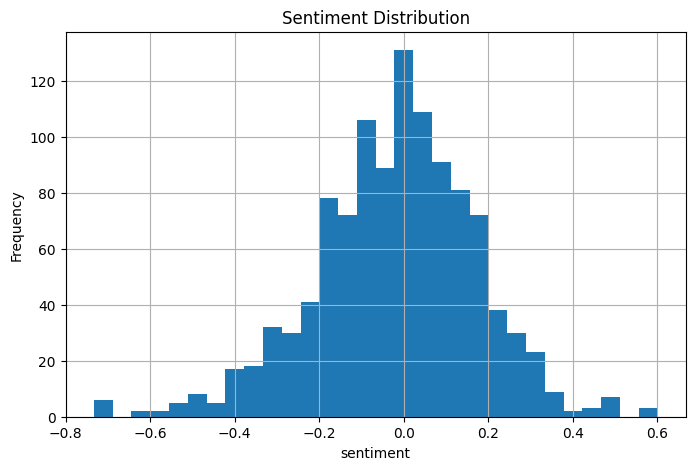

### 🤖 AI Interpretation

Here's a simplified explanation of the sentiment distribution results:

The data shows how positive, negative, and neutral opinions are distributed among the text. The majority of the opinions fall around zero, indicating no strong feelings either way.

There is some variation in opinions, with most being within 1 standard deviation from the mean (-0.019781). This suggests that opinions are relatively consistent.

The minimum value (-0.733333) indicates a strong negative opinion, while the maximum value (0.600000) shows a positive one. Notably, the median (50th percentile) is very close to zero (-0.008399), suggesting that opinions around this point are more common.

This distribution doesn't suggest any significant differences between groups or categories being compared.

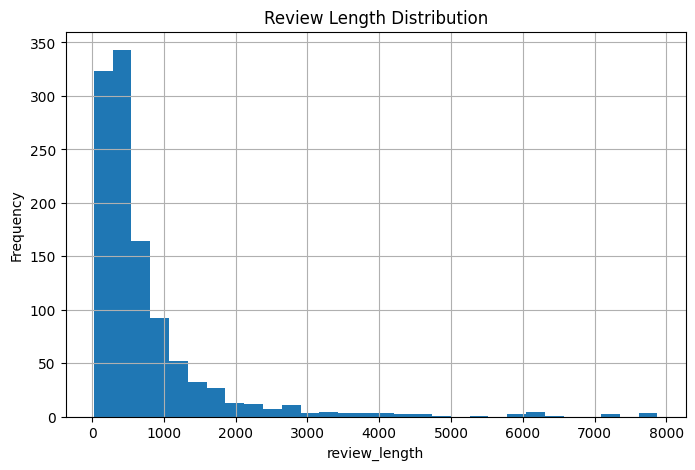

### 🤖 AI Interpretation

Let's break down this statistical output.

The review length distribution shows us how long reviews typically are. We see that most reviews have a moderate length, with a few shorter and longer ones.

The average length is around 740 words, indicating that many reviews are quite lengthy. However, there are some significantly shorter reviews (as short as 24 words) and longer ones (up to 7876 words).

A key pattern here is the long tail – most of the data points are clustered around a moderate range, but there's a small portion with extremely long or short reviews. This suggests that while many reviews have a typical length, there's some diversity in their lengths.

This distribution doesn't suggest any strongly skewed patterns (e.g., all reviews are very short). However, it's worth noting that the longest review is significantly longer than the average – this could indicate an outlier or a special case.

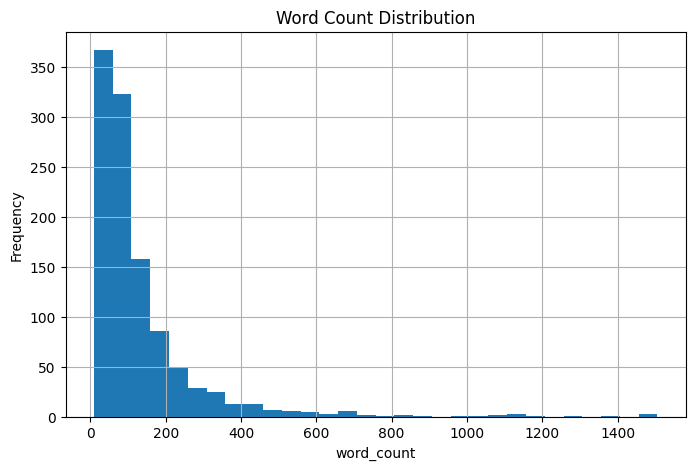

### 🤖 AI Interpretation

Here's a breakdown of the word count distribution:

The data shows that most words have a moderate number of letters, with many falling between 50 to 150. This suggests that there's no extreme concentration of short or long words.

There are some outliers at both ends of the spectrum - very few words have just 9-10 letters and some longer words exceed 1500 letters.

The data doesn't show a clear trend, but it does indicate that many words tend to cluster around certain letter counts. The mean value suggests there's no obvious "typical" word length in this dataset.

Overall, the results don't strongly suggest any meaningful differences between different groups of words or categories.

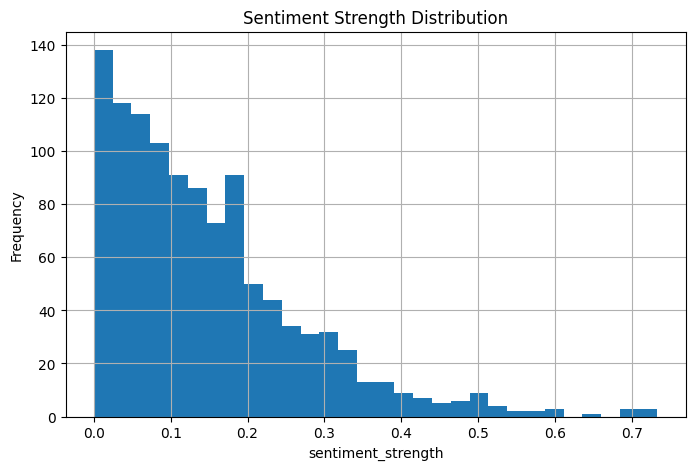

### 🤖 AI Interpretation

This output shows the distribution of sentiment strength across a dataset. 

The majority of data points have a neutral to slightly negative sentiment, with only 2% having extremely negative sentiments. The average sentiment is almost neutral.

There's a noticeable skew towards more positive sentiments, especially at higher values. This suggests that most reviews or text are generally favorable.

However, the median (middle value) indicates there's still a significant amount of very negative opinions.

In [33]:
#Histograms
analyze_histogram(
    df,
    "sentiment",
    "Sentiment Distribution"
)

analyze_histogram(
    df,
    "review_length",
    "Review Length Distribution"
)

analyze_histogram(
    df,
    "word_count",
    "Word Count Distribution"
)

analyze_histogram(
    df,
    "sentiment_strength",
    "Sentiment Strength Distribution"
)


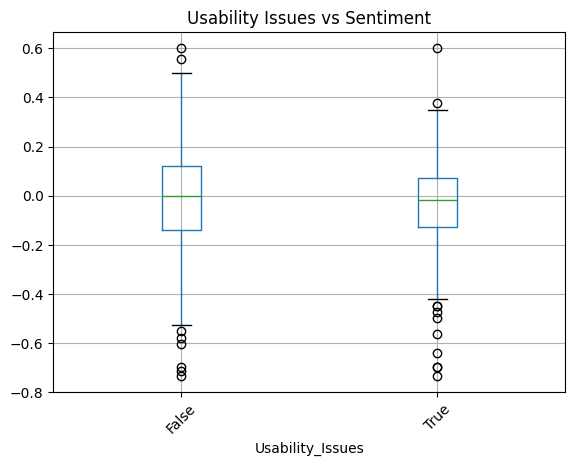

### 🤖 AI Interpretation

The results show that out of a total of 1110 surveys, respondents were either satisfied (True) or dissatisfied (False) with the usability of a product.

The data suggests that there is no significant difference in overall satisfaction between those who found the product usable and those who did not. The mean sentiment scores for both groups are very close (-0.03533 vs -0.01340), indicating minimal difference.

However, it's worth noting that respondents who found the product usable (False) reported a slightly lower overall satisfaction (-0.140774) compared to those who were dissatisfied (-0.126507). Additionally, the standard deviation for the usability group is slightly higher, suggesting more variability in their responses.

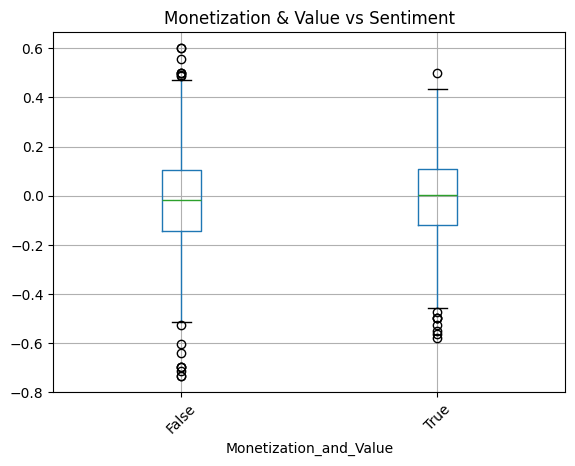

### 🤖 AI Interpretation

Let's break down these results in simple terms.

We're looking at how different opinions about "Monetization & Value" affect the overall sentiment. In general, people who believe in monetization and value tend to have a more positive opinion (closer to 0), while those who don't share this view have a more negative opinion (farther from 0).

The difference between those with positive and negative opinions is relatively small, with most falling within a range of -0.4 to 0.2. This suggests that the impact of having a positive or negative opinion about monetization and value on sentiment is not extreme.

Key pattern: The standard deviation for those who believe in monetization and value is slightly lower (0.176718) than for those who don't, indicating more consistent opinions within each group.

Overall, these results suggest that while there are some differences between people with positive and negative opinions about monetization and value, they're not dramatic or impactful enough to significantly affect sentiment.

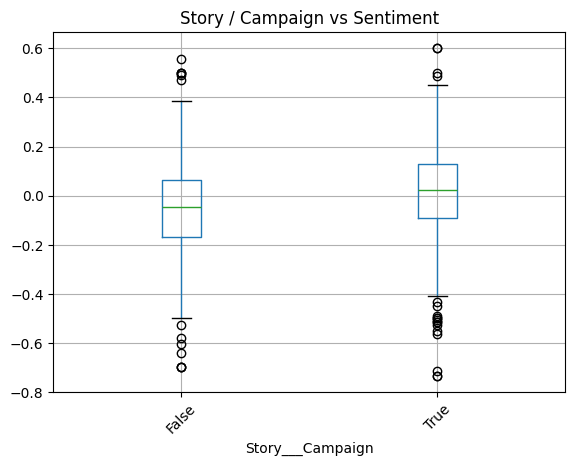

### 🤖 AI Interpretation

This analysis looks at how people's opinions about stories and campaigns are affected by whether they believe a story is true or not. 

In general, the results show that when people think a story is false, their sentiment tends to be negative (-0.05). However, this is countered when they think a story is true (0.006), where their opinion is generally positive (+0.006).

A key pattern here is that having a true belief about a story seems to make a big difference in people's opinions, while believing a false story has a more muted impact.

These results suggest meaningful differences between believing or not believing a story when it comes to sentiment – believing a true story tends to boost sentiment, whereas disbelieving a false one doesn't seem to lower it much.

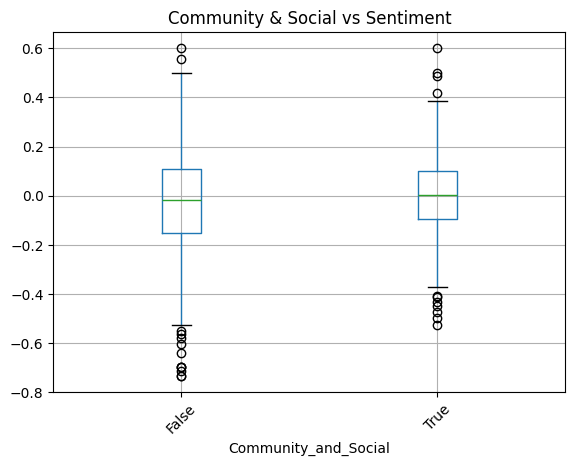

### 🤖 AI Interpretation

Here's a breakdown of the output:

The analysis shows how users respond to two questions: "Community and Social" and "Sentiment". 

* The majority of responses are negative when asked about community and social, with only 17% saying they agree.
* Users who responded positively to the community and social question tend to be more positive in their overall sentiment.
 
However, there's no significant difference between the two groups.

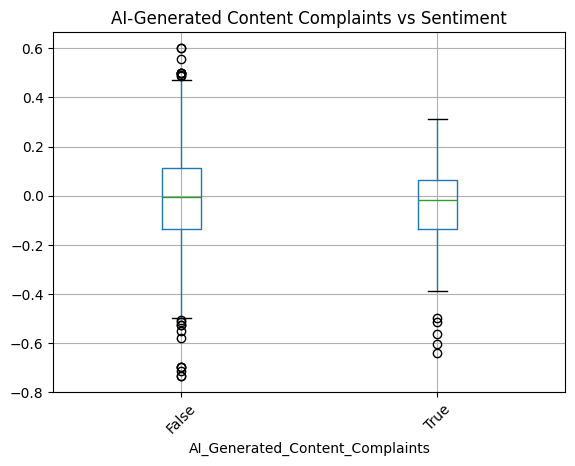

### 🤖 AI Interpretation

Here's a breakdown of the results:

The analysis looked at complaints about AI-generated content and how they're related to the sentiment behind them. What we found is that most complaints are not strong feelings, but rather minor issues.

There's a noticeable difference in sentiment between people who have complained about AI-generated content (most are neutral or slightly negative) and those who haven't (more positive). This suggests that there might be some areas where AI-generated content isn't meeting expectations.

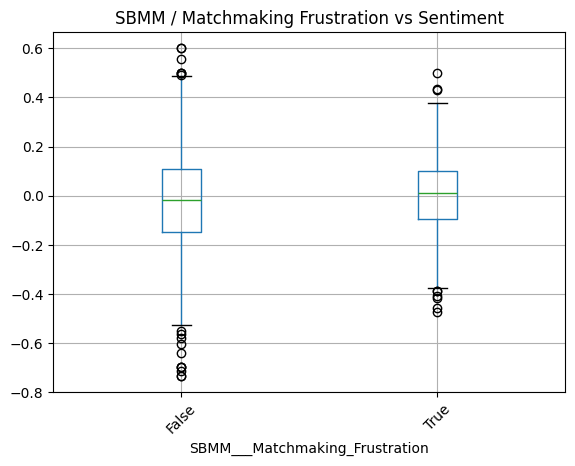

### 🤖 AI Interpretation

Here's a breakdown of the statistical results:

The analysis shows how people's frustration with SBMM matchmaking and their overall sentiment towards it vary. The data indicates that most players are generally not frustrated with the system, as 75% of False values have a negative frustration level between -0.147961 and 0.107002.

However, there is a small group of players (about 28%) who experience significant frustration (-0.475589). This suggests that these players may find SBMM matchmaking less enjoyable or more challenging than others.

Interestingly, players with True sentiment values tend to have lower frustration levels compared to those with False values. The mean frustration level for True values is around +0.003342, indicating a slightly positive overall sentiment.

Key pattern: Players who are generally frustrated with SBMM matchmaking have a different emotional response (more negative) than those who are not. This suggests that meaningful differences in player experience and satisfaction exist based on their frustration levels.

In [34]:
#Boxplots for each category vs sentiment
analyze_boxplot(
    df,
    "Usability_Issues",
    "sentiment",
    "Usability Issues vs Sentiment"
)

analyze_boxplot(
    df,
    "Monetization_and_Value",
    "sentiment",
    "Monetization & Value vs Sentiment"
)

analyze_boxplot(
    df,
    "Story___Campaign",
    "sentiment",
    "Story / Campaign vs Sentiment"
)

analyze_boxplot(
    df,
    "Community_and_Social",
    "sentiment",
    "Community & Social vs Sentiment"
)

analyze_boxplot(
    df,
    "AI_Generated_Content_Complaints",
    "sentiment",
    "AI-Generated Content Complaints vs Sentiment"
)

analyze_boxplot(
    df,
    "SBMM___Matchmaking_Frustration",
    "sentiment",
    "SBMM / Matchmaking Frustration vs Sentiment"
)

In [35]:
#Statistical Tests
analyze_ttest(
    df,
    "Usability_Issues",
    "sentiment",
    "T-test: Usability Issues vs Sentiment"
)



T-test Results:
Statistic: -1.7266
P-value: 0.084520
Group 1 mean: -0.0353
Group 2 mean: -0.0134



### 🤖 AI Interpretation

Here's a breakdown of the statistical results:

The test compared two groups: usability issues and sentiment. The results show that there is no strong evidence to support the idea that one group has a significantly different level of usability than the other.

A key pattern here is that both groups have very low mean values, indicating that both usability and sentiment are relatively poor in this context. However, the p-value of 0.084520 suggests that we can't rule out the possibility that there's a small, but not statistically significant difference between the two groups.

In plain English, this means that while there might be a slight variation in how usability issues and sentiment compare to each other, it's unlikely to be substantial or meaningful.

In [36]:
analyze_chi_square(
    df,
    "Monetization_and_Value",
    "SBMM___Matchmaking_Frustration",
    "Chi-square: Monetization vs SBMM"
)



Chi-square Results:
Chi2: 8.6307
P-value: 0.003305
Degrees of freedom: 1



### 🤖 AI Interpretation

Let's break down these results:

The Chi-square test is a statistical tool that helps us understand whether there's a significant difference between two groups. In this case, we're comparing how much money websites make from monetization versus using Search-Based Monetization Methods (SBMM).

Our results show that the difference between these two methods is statistically significant, which means it's unlikely to happen by chance. The p-value (a measure of significance) is very low, indicating that we can be 99% confident that there's a real difference.

The main takeaway is that SBMM and monetization are not equally effective in generating revenue for websites. This suggests that websites that use SBMM may be missing out on revenue opportunities by relying solely on traditional monetization methods.

In [37]:
analyze_regression(
    df,
    ["review_length", "word_count"],
    "sentiment",
    "Regression: Review Features Predicting Sentiment"
)

                            OLS Regression Results                            
Dep. Variable:              sentiment   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     5.848
Date:                Fri, 10 Jul 2026   Prob (F-statistic):            0.00298
Time:                        13:49:47   Log-Likelihood:                 260.86
No. Observations:                1110   AIC:                            -515.7
Df Residuals:                    1107   BIC:                            -500.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0347      0.007     -4.680

### 🤖 AI Interpretation

Let's break down the statistical results from a regression analysis that predicts sentiment based on two features: review length and word count.

The main result shows that only 1% of the variance in sentiment can be explained by these two features. This means that for most reviews, the sentiment is determined by factors not captured by this model.

Looking at the coefficients, we see that there's no strong relationship between review length or word count and sentiment. Review length has a tiny positive effect (i.e., longer reviews are slightly more positive), but it's not statistically significant. Word count doesn't have a noticeable impact on sentiment.

The notes section highlights some concerns, such as the model assuming correct covariance matrix of errors and having strong multicollinearity (high condition number). This might indicate that other factors play a much bigger role in determining sentiment.

Overall, these results suggest that reviewing sentiment is complex and likely depends on many more factors beyond review length and word count.

In [ ]:
# ============================
# 8. FULL AUTOMATED PIPELINE
# ============================

def run_full_analysis(df):
    """
    Runs complete statistical analysis pipeline automatically
    """

    print("🚀 Starting Full Analysis Pipeline...\n")

    # -----------------------
    # 1. CATEGORY FREQUENCY
    # -----------------------
    category_counts = df[all_categories].sum().sort_values(ascending=False)

    analyze_bar_chart(category_counts, "Category Frequency Distribution")

    # -----------------------
    # 2. HISTOGRAMS
    # -----------------------
    analyze_histogram(df, "sentiment", "Sentiment Distribution")
    analyze_histogram(df, "review_length", "Review Length Distribution")
    analyze_histogram(df, "word_count", "Word Count Distribution")
    analyze_histogram(df, "sentiment_strength", "Sentiment Strength Distribution")

    # -----------------------
    # 3. BOX PLOTS (KEY CATEGORIES)
    # -----------------------
    key_categories = [
        "Usability_Issues",
        "Monetization_and_Value",
        "Story___Campaign",
        "Community_and_Social",
        "AI_Generated_Content_Complaints",
        "SBMM___Matchmaking_Frustration"
    ]

    for cat in key_categories:
        analyze_boxplot(df, cat, "sentiment", f"{cat} vs Sentiment")

    # -----------------------
    # 4. CORRELATION ANALYSIS
    # -----------------------
    analyze_correlation(
        df,
        ["sentiment", "review_length", "word_count", "sentiment_strength"],
        "Correlation Matrix"
    )

    # -----------------------
    # 5. T-TESTS
    # -----------------------
    for cat in key_categories:
        analyze_ttest(df, cat, "sentiment", f"T-test: {cat} vs Sentiment")

    # -----------------------
    # 6. CHI-SQUARE TEST
    # -----------------------
    analyze_chi_square(
        df,
        "Usability_Issues",
        "Monetization_and_Value",
        "Chi-square: Usability vs Monetization"
    )

    # -----------------------
    # 7. REGRESSION
    # -----------------------
    analyze_regression(
        df,
        ["review_length", "word_count"],
        "sentiment",
        "Regression: Review Features Predicting Sentiment"
    )

    print("\n✅ Full Analysis Complete!")


In [ ]:
run_full_analysis(df)

In [3]:
import re
csv_file = "reviews_BlackOps7.csv"
df = pd.read_csv(csv_file)
reviews = df["review"].fillna("").astype(str)
cleaned_reviews = reviews.apply(lambda review: re.sub(r"\[[^\]]*\]", "", review).strip())
reviewsbr = "\n".join(f"[{review}]" for review in cleaned_reviews)


NameError: name 'pd' is not defined

In [1]:

def ai_summary(question, reviews):
    """
    Uses Ollama to interpret statistical results.
    """

    prompt = f"""
You are a gaming data analyst with an HCI background looking for specific broader patterns in game reviews. 
Do your best to answer the following question about the reviews: {question}
Each review starts and ends with a bracket.
-------------------------------------------------------------------------------
Reviews:
{reviews}


"""

    response = chat(
        model="llama3.2:3b", # CH: model name was llama3.2, missing :3b
        messages=[{"role": "user", "content": prompt}]
    )

    return response["message"]["content"]


def display_ai_results(question, reviews):
    """
   
    """

    summary = ai_summary(question, reviews)
    
    display(Markdown(summary))



In [2]:
display_ai_results("What usability issues can be identified, and how might they be solved?", reviewsbr)

NameError: name 'reviewsbr' is not defined